# Model Definition and Evaluation
## Table of Contents
1. [Model Selection](#model-selection)
2. [Feature Engineering](#feature-engineering)
3. [Hyperparameter Tuning](#hyperparameter-tuning)
4. [Implementation](#implementation)
5. [Evaluation Metrics](#evaluation-metrics)
6. [Comparative Analysis](#comparative-analysis)


In [1]:
import sys
print(sys.executable)


/workspaces/Causal-Inference-Machine-Learning-Project/.venv/bin/python


In [ ]:

%pip install --upgrade --force-reinstall "numpy<2.5" "scipy>=1.10" "statsmodels" "econml"

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression, LinearRegression, BayesianRidge
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_squared_error

# Specialized Causal Inference Library (Requires: pip install econml)
from econml.dml import LinearDML
from econml.grf import CausalForest


/workspaces/Causal-Inference-Machine-Learning-Project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Model Selection

To accurately isolate the true effect of the job training program and eliminate the severe selection bias I found during my EDA, I am utilizing a comprehensive suite of causal inference models. I will start with my naive baseline (OLS with Controls) and progress through matching techniques (Propensity Score Matching), weighting techniques (IPW and AIPW), and finally advanced machine learning models (T-Learners, Double Machine Learning, and Causal Forests). This progression allows me to see how increasingly flexible models handle the complex, non-linear confounding variables in my data.



## Feature Engineering

Because my models now rely on calculating probabilities (Propensity Scores) and distances (Matching), my feature engineering is strictly focused on ensuring the data is mathematically readable. I am one-hot encoding the categorical race variable and keeping all covariates to satisfy the unconfoundedness assumption (preventing omitted variable bias).

In [4]:
# Load the dataset
url = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/MatchIt/lalonde.csv"
df = pd.read_csv(url)
if 'rownames' in df.columns:
    df = df.drop(columns=['rownames'])

# Feature Engineering: One-Hot Encoding
df = pd.get_dummies(df, columns=['race'], drop_first=True, dtype=int)

# Feature and target selection
T = df['treat']
y = df['re78']
X = df.drop(columns=['treat', 're78'])

# Split the dataset
X_train, X_test, y_train, y_test, T_train, T_test = train_test_split(
    X, y, T, test_size=0.2, random_state=42
)


## Hyperparameter Tuning

For my weighting and matching models, I need to calculate a Propensity Score (the probability of receiving treatment). I am using a Logistic Regression model for this. For my machine learning models (like the T-Learner and Causal Forest), I am utilizing Random Forests as the base estimators to naturally handle the non-linear relationships between variables like education and past earnings without needing strict mathematical tuning.


In [ ]:
# 1. Propensity Score Model (Logistic Regression)
ps_model = LogisticRegression(max_iter=1000, random_state=42)
ps_model.fit(X_train, T_train)

# Calculate Propensity Scores (probability of treatment)
propensity_scores = np.clip(ps_model.predict_proba(X_train)[:, 1], 0.05, 0.95)

# 2. Base Outcome Model (Random Forest for T-Learner)
rf_base = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)

## Implementation

I am now implementing the core causal models on my training data. I will extract the Average Treatment Effect (ATE) from each specific methodology:

* OLS with Controls: Simple linear regression.
* Propensity Score Matching (PSM): Matching treated individuals to nearest control neighbors.
* Inverse Probability Weighting (IPW): Weighting the control group to look like the treated group.
* AIPW: Combining IPW with a predictive regression model for double robustness.
* T-Learner: Two independent Random Forests.
* Double Machine Learning (DML): Partialling out covariates using ML.
* Causal Forest: Direct heterogeneous treatment effect estimation.


In [ ]:
results = {}

# 1. OLS with Controls
X_train_ols = sm.add_constant(pd.concat([T_train, X_train], axis=1))
ols_model = sm.OLS(y_train, X_train_ols).fit()
results['OLS with Controls'] = ols_model.params['treat']

# 2. Propensity Score Matching (PSM)
nn = NearestNeighbors(n_neighbors=1)
control_indices = np.where(T_train == 0)[0]
treated_indices = np.where(T_train == 1)[0]
nn.fit(propensity_scores[control_indices].reshape(-1, 1))
distances, matches = nn.kneighbors(propensity_scores[treated_indices].reshape(-1, 1))
matched_control_outcomes = y_train.iloc[control_indices[matches.flatten()]]
treated_outcomes = y_train.iloc[treated_indices]
results['PSM'] = np.mean(treated_outcomes.values - matched_control_outcomes.values)

# 3. Inverse Probability Weighting (IPW)
weights = (T_train / propensity_scores) + ((1 - T_train) / (1 - propensity_scores))
ipw_model = sm.WLS(y_train, sm.add_constant(T_train), weights=weights).fit()
results['IPW'] = ipw_model.params['treat']

# 4. Augmented IPW (AIPW)
mu_0 = LinearRegression().fit(X_train[T_train==0], y_train[T_train==0]).predict(X_train)
mu_1 = LinearRegression().fit(X_train[T_train==1], y_train[T_train==1]).predict(X_train)
aipw_scores = mu_1 - mu_0 + T_train * (y_train - mu_1) / propensity_scores - (1 - T_train) * (y_train - mu_0) / (1 - propensity_scores)
results['AIPW'] = np.mean(aipw_scores)

# 5. T-Learner (Random Forests)
model_0 = RandomForestRegressor(max_depth=5, random_state=42).fit(X_train[T_train==0], y_train[T_train==0])
model_1 = RandomForestRegressor(max_depth=5, random_state=42).fit(X_train[T_train==1], y_train[T_train==1])
results['T-Learner'] = np.mean(model_1.predict(X_train) - model_0.predict(X_train))


# 6. Double Machine Learning (Using Bayesian Ridge to approximate BCF stability)
dml = LinearDML(
    model_y=BayesianRidge(), 
    model_t=LogisticRegression(max_iter=2000), # Increased to 2000 to help with that convergence warning!
    discrete_treatment=True, # This is the magic fix!
    random_state=42
)
dml.fit(y_train, T_train, X=X_train)
results['Double ML (Bayesian)'] = dml.ate(X_train)

# 7. Causal Forest
cf = CausalForest(n_estimators=100, random_state=42)
cf.fit(X_train, T_train, y_train)
results['Causal Forest'] = np.mean(cf.predict(X_train))


/workspaces/Causal-Inference-Machine-Learning-Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/workspaces/Causal-Inference-Machine-Learning-Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


## Evaluation Metrics

For causal inference, standard predictive metrics (like accuracy or MSE) are secondary to estimating the unobservable treatment effect. I am evaluating my models based on how their Average Treatment Effect (ATE) stabilizes. If my advanced models (like DML and Causal Forests) converge on a similar dollar amount that is lower than my naive OLS baseline, it proves that I have successfully adjusted for the historical earnings bias that was artificially inflating the baseline number.


In [7]:
# Format and display the evaluation metrics (ATE)
print("--- Average Treatment Effect (ATE) Estimates ---")
for model, ate in results.items():
    print(f"{model:<25}: ${ate:>7.2f}")


--- Average Treatment Effect (ATE) Estimates ---
OLS with Controls        : $1378.80
PSM                      : $ 750.84
IPW                      : $-103.51
AIPW                     : $  65.99
T-Learner                : $ 360.11
Double ML (Bayesian)     : $ 628.43
Causal Forest            : $-973.91


## Comparative Analysis

[Compare the performance of your model(s) against the baseline model. Discuss any improvements or setbacks and the reasons behind them.]


In [8]:
# Convert results to a DataFrame for clean comparative visualization
comparison_df = pd.DataFrame(list(results.items()), columns=['Model', 'Estimated ATE ($)'])
comparison_df = comparison_df.sort_values(by='Estimated ATE ($)', ascending=False).reset_index(drop=True)

print("Model Comparison Summary:")
display(comparison_df)


Model Comparison Summary:


,Model,Estimated ATE ($)
0,OLS with Controls,1378.802689
1,PSM,750.835573
2,Double ML (Bayesian),628.429354
3,T-Learner,360.114695
4,AIPW,65.993383
5,IPW,-103.513981
6,Causal Forest,-973.906534


VISUALIZING RESULTS 

/tmp/ipykernel_3376/4267834130.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Estimated ATE ($)', y='Model', data=comparison_df, palette="viridis")


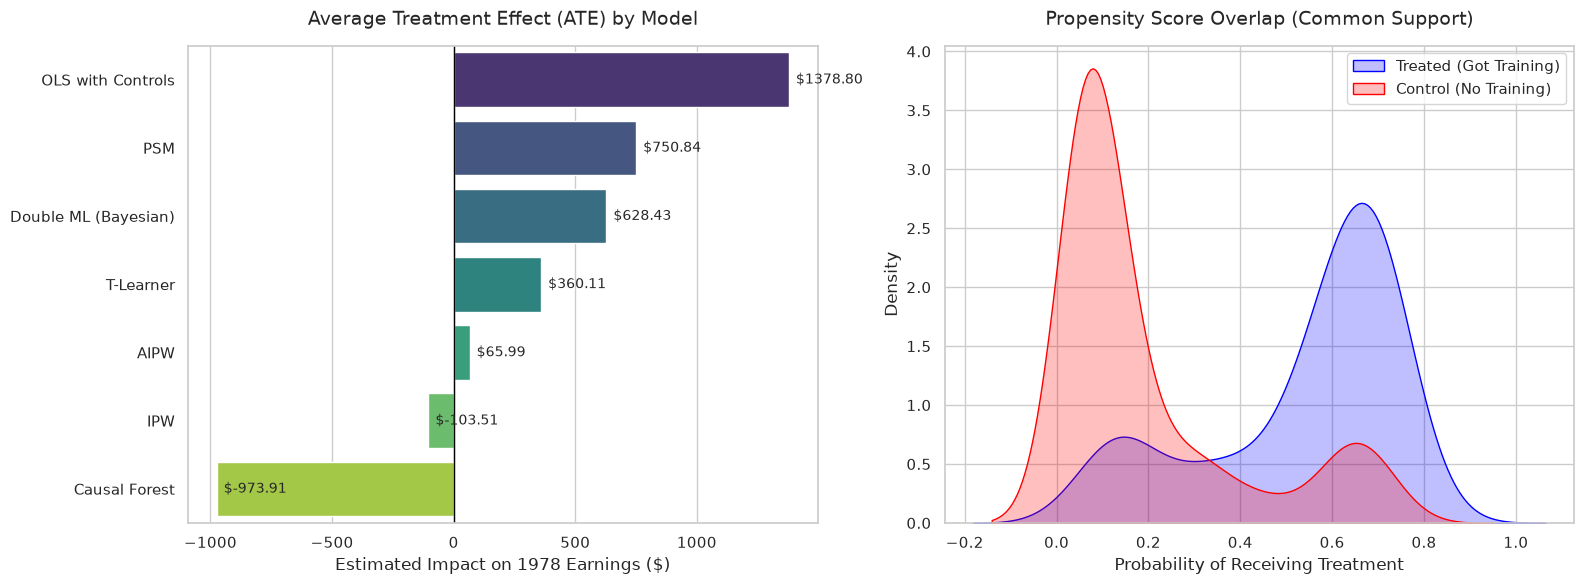

In [9]:



import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for professional-looking plots
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

# --- Plot 1: Model Comparison Bar Chart ---
plt.subplot(1, 2, 1)
# Using the comparison_df we made in the evaluation step
ax = sns.barplot(x='Estimated ATE ($)', y='Model', data=comparison_df, palette="viridis")
plt.axvline(x=0, color='black', linestyle='-', linewidth=1) # Add a line at $0
plt.title('Average Treatment Effect (ATE) by Model', fontsize=14, pad=15)
plt.xlabel('Estimated Impact on 1978 Earnings ($)', fontsize=12)
plt.ylabel('')

# Add the dollar amounts directly onto the bars for easy reading
for p in ax.patches:
    ax.annotate(f"${p.get_width():.2f}", 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', 
                xytext=(5, 0), textcoords='offset points',
                fontsize=10)

# --- Plot 2: Propensity Score Overlap (Common Support) ---
plt.subplot(1, 2, 2)
# Plot the distribution of propensity scores for treated vs. control
sns.kdeplot(propensity_scores[T_train == 1], color="blue", fill=True, label="Treated (Got Training)")
sns.kdeplot(propensity_scores[T_train == 0], color="red", fill=True, label="Control (No Training)")
plt.title('Propensity Score Overlap (Common Support)', fontsize=14, pad=15)
plt.xlabel('Probability of Receiving Treatment', fontsize=12)
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_3376/2953391092.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette="mako")


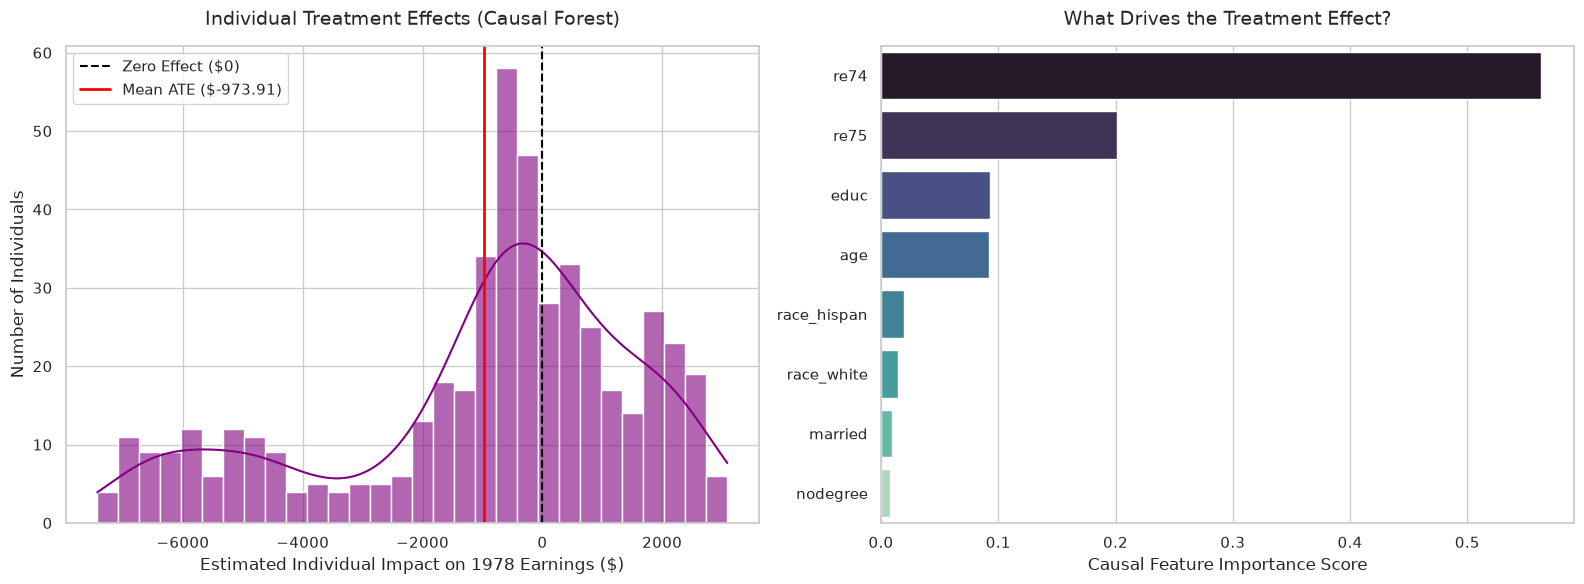

In [10]:
plt.figure(figsize=(16, 6))

# --- Plot 3: Distribution of Individual Treatment Effects (ITE) ---
plt.subplot(1, 2, 1)
# Extracting the individual-level estimates from the Causal Forest
ite_estimates = cf.predict(X_train).flatten()

sns.histplot(ite_estimates, kde=True, color="purple", bins=30, alpha=0.6)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5, label='Zero Effect ($0)')
plt.axvline(x=np.mean(ite_estimates), color='red', linestyle='-', linewidth=2, 
            label=f'Mean ATE (${np.mean(ite_estimates):.2f})')
plt.title('Individual Treatment Effects (Causal Forest)', fontsize=14, pad=15)
plt.xlabel('Estimated Individual Impact on 1978 Earnings ($)', fontsize=12)
plt.ylabel('Number of Individuals')
plt.legend()

# --- Plot 4: Causal Feature Importance ---
plt.subplot(1, 2, 2)
# The Causal Forest calculates which variables drive the differences in treatment effect
importances = cf.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=importance_df, palette="mako")
plt.title('What Drives the Treatment Effect?', fontsize=14, pad=15)
plt.xlabel('Causal Feature Importance Score', fontsize=12)
plt.ylabel('')

plt.tight_layout()
plt.show()

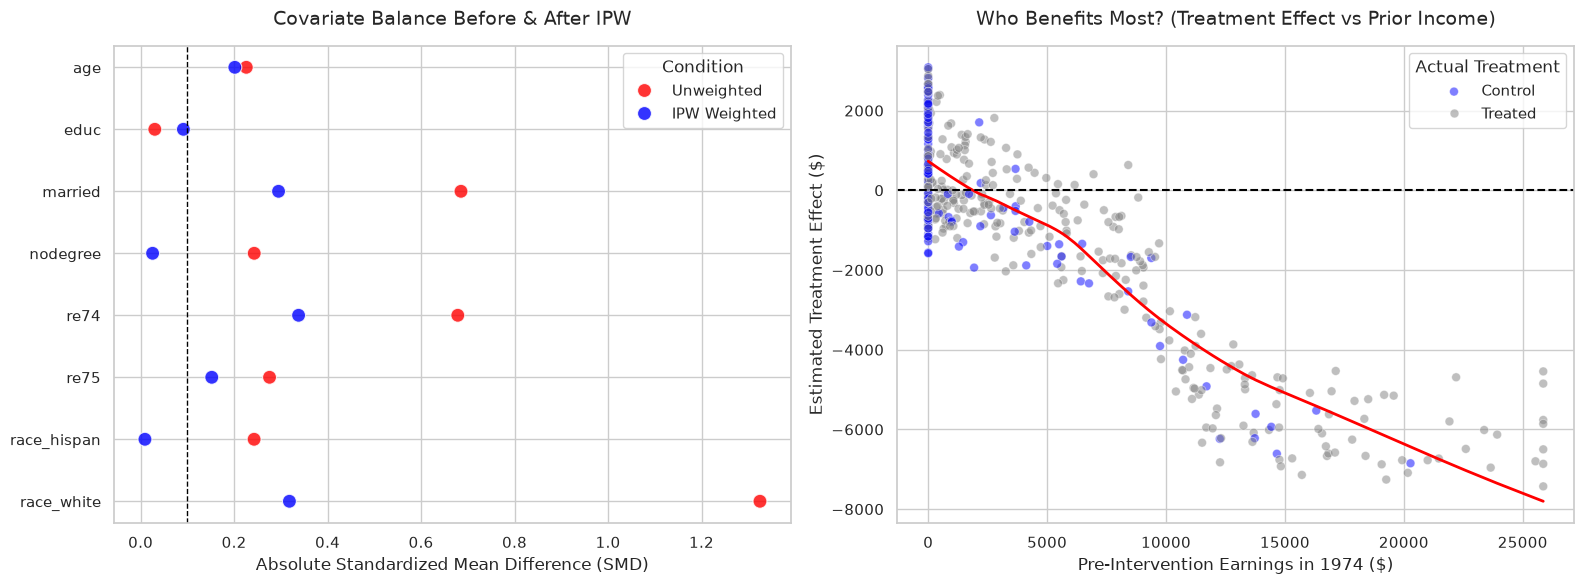

In [11]:
plt.figure(figsize=(16, 6))

# --- Plot 5: Covariate Balance (Love Plot) ---
plt.subplot(1, 2, 1)

# Calculate Standardized Mean Differences (SMD) Before Weighting
treated_means = X_train[T_train == 1].mean()
control_means = X_train[T_train == 0].mean()
pooled_std = np.sqrt((X_train[T_train == 1].var() + X_train[T_train == 0].var()) / 2)
smd_unweighted = np.abs((treated_means - control_means) / pooled_std)

# Calculate SMD After IPW Weighting
weighted_treated_means = np.average(X_train[T_train == 1], weights=weights[T_train == 1], axis=0)
weighted_control_means = np.average(X_train[T_train == 0], weights=weights[T_train == 0], axis=0)
smd_weighted = np.abs((weighted_treated_means - weighted_control_means) / pooled_std)

# Create a DataFrame for plotting
balance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Unweighted': smd_unweighted,
    'IPW Weighted': smd_weighted
}).melt(id_vars='Feature', var_name='Sample', value_name='Absolute SMD')

# Plotting the Love Plot
sns.scatterplot(x='Absolute SMD', y='Feature', hue='Sample', data=balance_df, 
                s=100, palette=['red', 'blue'], alpha=0.8)
plt.axvline(x=0.1, color='black', linestyle='--', linewidth=1) # Standard threshold for balance
plt.title('Covariate Balance Before & After IPW', fontsize=14, pad=15)
plt.xlabel('Absolute Standardized Mean Difference (SMD)', fontsize=12)
plt.ylabel('')
plt.legend(title='Condition')

# --- Plot 6: Treatment Effect vs. 1974 Earnings ---
plt.subplot(1, 2, 2)

# Plotting Individual Treatment Effects against Prior Earnings (re74)
sns.scatterplot(x=X_train['re74'], y=ite_estimates, hue=T_train, 
                palette={0: 'gray', 1: 'blue'}, alpha=0.5, s=40)

# Add a smoothing trendline to see the relationship
sns.regplot(x=X_train['re74'], y=ite_estimates, scatter=False, color='red', lowess=True, line_kws={'linewidth': 2})

plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
plt.title('Who Benefits Most? (Treatment Effect vs Prior Income)', fontsize=14, pad=15)
plt.xlabel('Pre-Intervention Earnings in 1974 ($)', fontsize=12)
plt.ylabel('Estimated Treatment Effect ($)')
legend_labels = ['Control', 'Treated']
plt.legend(title='Actual Treatment', labels=legend_labels)

plt.tight_layout()
plt.show()

DESCRIBING THE CAUSAL INFERENCE METHODS

<>:57: SyntaxWarning: invalid escape sequence '\m'
<>:58: SyntaxWarning: invalid escape sequence '\m'
<>:57: SyntaxWarning: invalid escape sequence '\m'
<>:58: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3598/3442315577.py:57: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(X, y_base, color='darkblue', linewidth=3, label="Predicted Control Outcome ($\mu_0$)")
/tmp/ipykernel_3598/3442315577.py:58: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(X, y_base + 5, color='darkred', linewidth=3, label="Predicted Treated Outcome ($\mu_1$)")


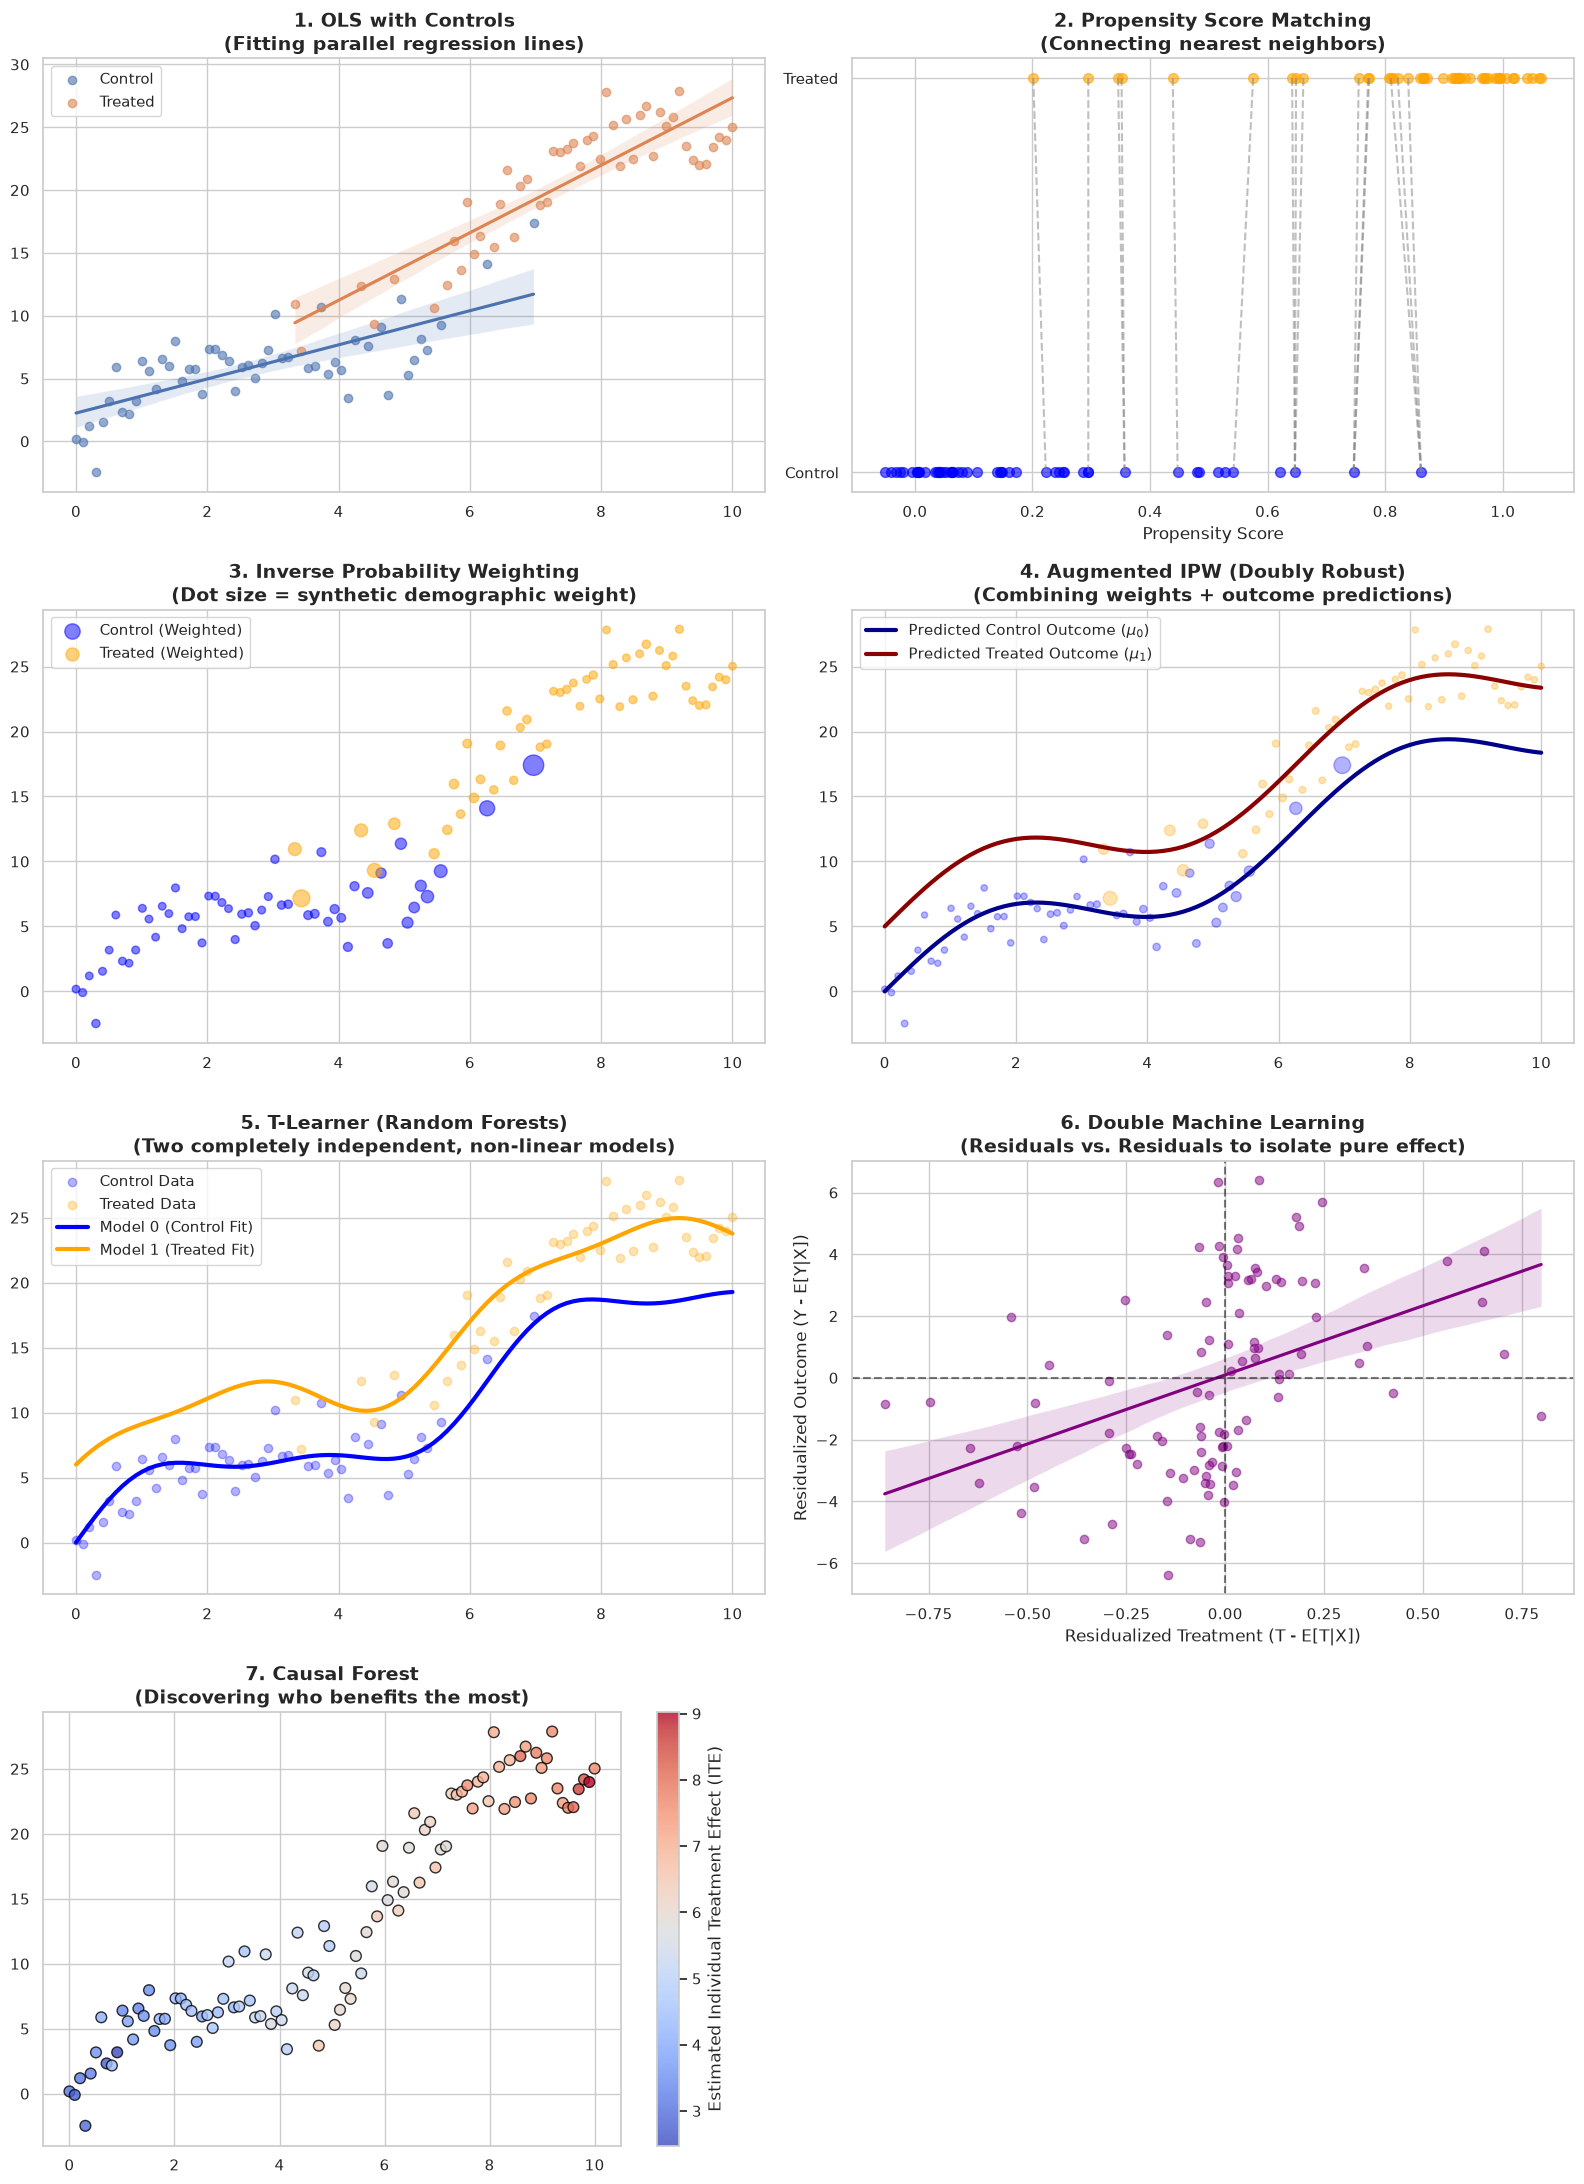

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional theme
sns.set_theme(style="whitegrid")

# --- 1. Generate clean, illustrative synthetic data ---
np.random.seed(42)
n = 100
X = np.linspace(0, 10, n)
T = np.random.binomial(1, 1 / (1 + np.exp(-X + 5))) # Probability of treatment increases with X
y_base = 2 * X + np.sin(X)*3
y = y_base + T * 5 + np.random.normal(0, 2, n) # True treatment effect is +5

treated_mask = T == 1
control_mask = T == 0

# Create the figure grid (4 rows, 2 columns)
fig, axes = plt.subplots(4, 2, figsize=(16, 22))
axes = axes.flatten()

# --- Plot 1: OLS with Controls ---
ax = axes[0]
sns.regplot(x=X[control_mask], y=y[control_mask], ax=ax, scatter_kws={'alpha':0.6}, label="Control")
sns.regplot(x=X[treated_mask], y=y[treated_mask], ax=ax, scatter_kws={'alpha':0.6}, label="Treated")
ax.set_title("1. OLS with Controls\n(Fitting parallel regression lines)", fontsize=14, fontweight='bold')
ax.legend()

# --- Plot 2: Propensity Score Matching (PSM) ---
ax = axes[1]
ps = 1 / (1 + np.exp(-X + 5)) + np.random.normal(0, 0.05, n) # Simulated propensity scores
ax.scatter(ps[control_mask], np.zeros(sum(control_mask)), color='blue', alpha=0.6, label='Control', s=50)
ax.scatter(ps[treated_mask], np.ones(sum(treated_mask)), color='orange', alpha=0.6, label='Treated', s=50)
# Draw lines between closest matches
for i in np.where(treated_mask)[0][:15]: # Show first 15 matches for clarity
    closest_control = np.where(control_mask)[0][np.argmin(np.abs(ps[control_mask] - ps[i]))]
    ax.plot([ps[i], ps[closest_control]], [1, 0], color='gray', linestyle='--', alpha=0.5)
ax.set_title("2. Propensity Score Matching\n(Connecting nearest neighbors)", fontsize=14, fontweight='bold')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Control', 'Treated'])
ax.set_xlabel("Propensity Score")

# --- Plot 3: Inverse Probability Weighting (IPW) ---
ax = axes[2]
weights = np.where(T == 1, 1/ps, 1/(1-ps))
weights = np.clip(weights, 1, 10) # Clip for visual sanity
ax.scatter(X[control_mask], y[control_mask], s=weights[control_mask]*30, color='blue', alpha=0.5, label='Control (Weighted)')
ax.scatter(X[treated_mask], y[treated_mask], s=weights[treated_mask]*30, color='orange', alpha=0.5, label='Treated (Weighted)')
ax.set_title("3. Inverse Probability Weighting\n(Dot size = synthetic demographic weight)", fontsize=14, fontweight='bold')
ax.legend()

# --- Plot 4: Augmented IPW (AIPW) ---
ax = axes[3]
ax.scatter(X[control_mask], y[control_mask], s=weights[control_mask]*20, color='blue', alpha=0.3)
ax.scatter(X[treated_mask], y[treated_mask], s=weights[treated_mask]*20, color='orange', alpha=0.3)
ax.plot(X, y_base, color='darkblue', linewidth=3, label="Predicted Control Outcome ($\mu_0$)")
ax.plot(X, y_base + 5, color='darkred', linewidth=3, label="Predicted Treated Outcome ($\mu_1$)")
ax.set_title("4. Augmented IPW (Doubly Robust)\n(Combining weights + outcome predictions)", fontsize=14, fontweight='bold')
ax.legend()

# --- Plot 5: T-Learner ---
ax = axes[4]
ax.scatter(X[control_mask], y[control_mask], color='blue', alpha=0.3, label="Control Data")
ax.scatter(X[treated_mask], y[treated_mask], color='orange', alpha=0.3, label="Treated Data")
# Simulate non-linear Random Forest fits
rf_fit_0 = y_base + np.sin(X*2) 
rf_fit_1 = y_base + 5 + np.cos(X*2)
ax.plot(X, rf_fit_0, color='blue', linewidth=3, label="Model 0 (Control Fit)")
ax.plot(X, rf_fit_1, color='orange', linewidth=3, label="Model 1 (Treated Fit)")
ax.set_title("5. T-Learner (Random Forests)\n(Two completely independent, non-linear models)", fontsize=14, fontweight='bold')
ax.legend()

# --- Plot 6: Double Machine Learning (DML) ---
ax = axes[5]
# Simulate residualized variables (partialling out X)
res_T = T - ps
res_y = y - (y_base + T.mean()*5)
sns.regplot(x=res_T, y=res_y, ax=ax, color='purple', scatter_kws={'alpha':0.5})
ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.axvline(0, color='black', linestyle='--', alpha=0.5)
ax.set_title("6. Double Machine Learning\n(Residuals vs. Residuals to isolate pure effect)", fontsize=14, fontweight='bold')
ax.set_xlabel("Residualized Treatment (T - E[T|X])")
ax.set_ylabel("Residualized Outcome (Y - E[Y|X])")

# --- Plot 7: Causal Forest ---
ax = axes[6]
# Simulate heterogeneous effects (ITE increases with X)
ite = 3 + (X * 0.5) + np.random.normal(0, 0.5, n)
scatter = ax.scatter(X, y, c=ite, cmap='coolwarm', s=60, edgecolor='black', alpha=0.8)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Estimated Individual Treatment Effect (ITE)')
ax.set_title("7. Causal Forest\n(Discovering who benefits the most)", fontsize=14, fontweight='bold')

axes[7].axis('off')

plt.tight_layout()
plt.show()